
# Other Classifiers: Support Vector Machines (SVM) and Linear Discriminant Analysis (LDA)



## 1. Libraries and setup

SVM is very sensitive to feature scale, so the implementation uses `StandardScaler` inside a scikit-learn `Pipeline`. LDA is fitted in the same workflow for consistency and leakage prevention.


In [1]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import (
    load_wine,
    make_blobs,
    make_circles,
)
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis,
)
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    train_test_split,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titleweight": "bold",
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")



## 2. Small helper functions

Only repeated evaluation and two-dimensional plotting steps are wrapped in functions. Model fitting remains explicit.


In [2]:

def classification_metrics(y_true, y_pred, model_name):
    """Return compact classification metrics."""
    return pd.DataFrame([{
        "model": model_name,
        "accuracy": accuracy_score(y_true, y_pred),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted"),
    }]).round(3)


def plot_confusion(y_true, y_pred, labels, title):
    """Plot a labeled confusion matrix."""
    cm = confusion_matrix(y_true, y_pred, labels=range(len(labels)))
    cm_df = pd.DataFrame(
        cm,
        index=[f"Actual {label}" for label in labels],
        columns=[f"Predicted {label}" for label in labels],
    )
    plt.figure(figsize=(6.5, 5))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
    plt.title(title)
    plt.ylabel("Actual class")
    plt.xlabel("Predicted class")
    plt.tight_layout()
    plt.show()
    return cm_df


def plot_2d_classifier(model, X, y, title, feature_names=("Feature 1", "Feature 2"),
                       highlight_support=False):
    """Plot the decision regions of a fitted two-feature classifier."""
    fig, ax = plt.subplots(figsize=(7.5, 5.8))
    DecisionBoundaryDisplay.from_estimator(
        model,
        X,
        response_method="predict",
        alpha=0.25,
        ax=ax,
        grid_resolution=250,
    )
    scatter = ax.scatter(
        X[:, 0], X[:, 1], c=y, edgecolor="black", s=48, alpha=0.85
    )

    if highlight_support:
        estimator = model.named_steps["model"] if hasattr(model, "named_steps") else model
        if hasattr(estimator, "support_"):
            support_points = X[estimator.support_]
            ax.scatter(
                support_points[:, 0],
                support_points[:, 1],
                s=150,
                facecolors="none",
                edgecolors="black",
                linewidths=1.8,
                label="Support vectors",
            )
            ax.legend()

    ax.set_title(title)
    ax.set_xlabel(feature_names[0])
    ax.set_ylabel(feature_names[1])
    plt.tight_layout()
    plt.show()



# Part A — Support Vector Machines

## 3. Linear SVM: margin and support vectors

**Method idea.** A linear SVM searches for the separating hyperplane with the widest possible margin. The observations closest to that boundary are the **support vectors**; they have the strongest influence on the fitted classifier.


Number of support vectors by class: [5 5]


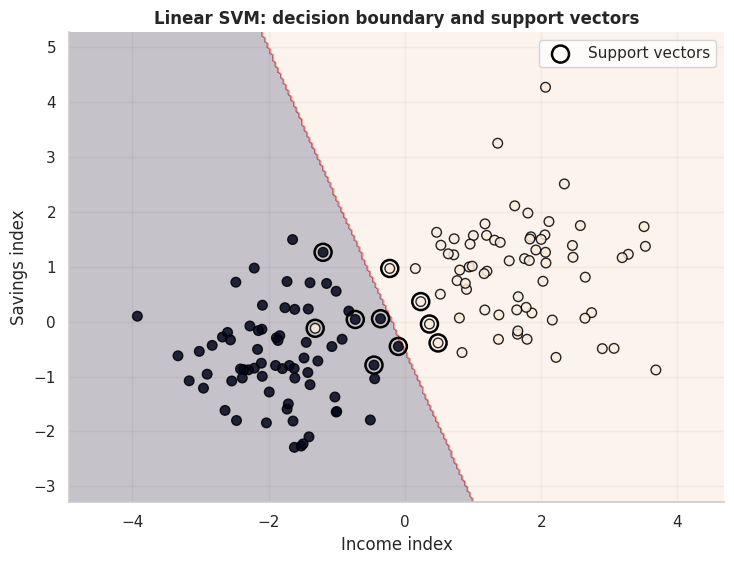

In [3]:

# Two compact, mostly separable classes.
X_linear, y_linear = make_blobs(
    n_samples=140,
    centers=[(-1.7, -0.6), (1.6, 0.8)],
    cluster_std=[0.85, 0.90],
    random_state=RANDOM_STATE,
)

linear_svm = SVC(kernel="linear", C=1.0)
linear_svm.fit(X_linear, y_linear)

print("Number of support vectors by class:", linear_svm.n_support_)
plot_2d_classifier(
    linear_svm,
    X_linear,
    y_linear,
    title="Linear SVM: decision boundary and support vectors",
    feature_names=("Income index", "Savings index"),
    highlight_support=True,
)



**Interpretation.** The circled observations define the margin. Points far from the boundary usually have little effect on its location. A new case is classified according to the side of the hyperplane on which it falls, not through a sequence of rules.



## 4. Soft margin and the `C` parameter

Real classes overlap. `C` controls how strongly the model penalizes training errors.

- **Small `C`:** wider, more tolerant margin; stronger regularization.
- **Large `C`:** narrower margin; prioritizes training accuracy and can overfit.


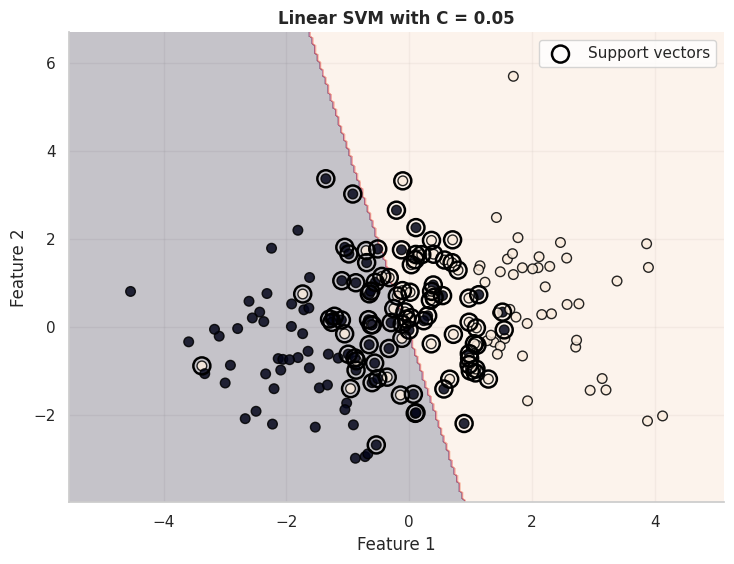

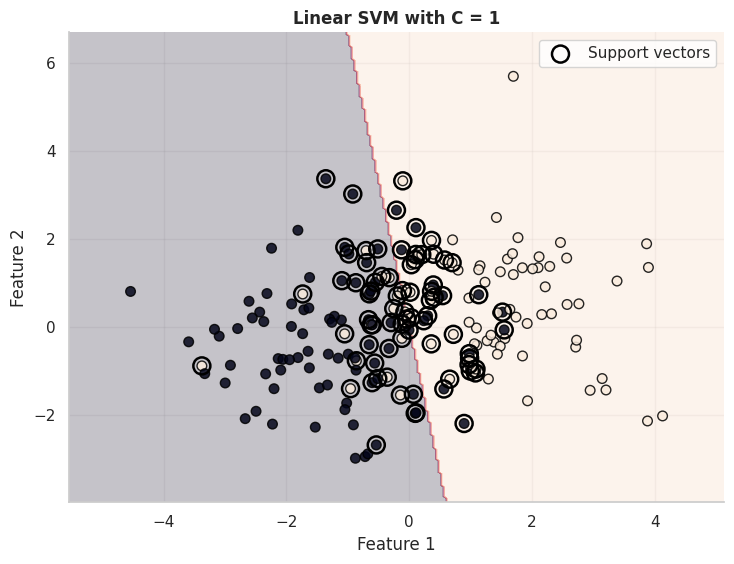

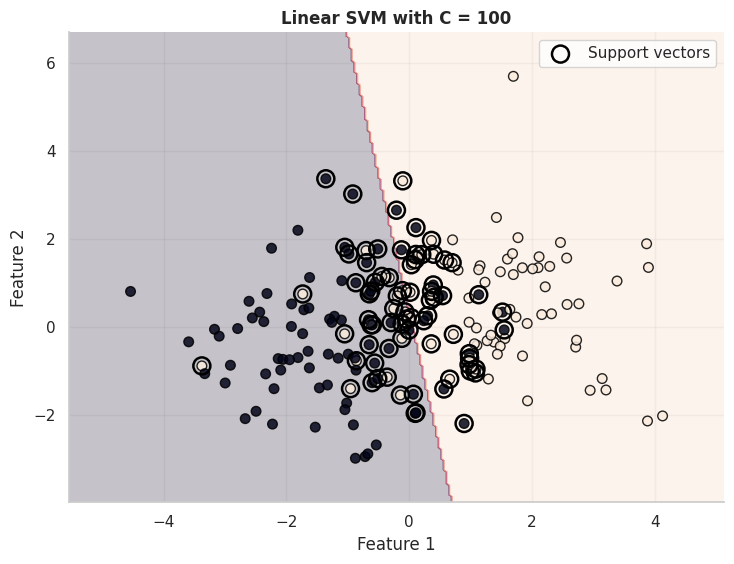

In [4]:

X_overlap, y_overlap = make_blobs(
    n_samples=180,
    centers=[(-1.0, -0.3), (1.0, 0.5)],
    cluster_std=1.35,
    random_state=RANDOM_STATE,
)

for c_value in [0.05, 1, 100]:
    model = SVC(kernel="linear", C=c_value)
    model.fit(X_overlap, y_overlap)
    plot_2d_classifier(
        model,
        X_overlap,
        y_overlap,
        title=f"Linear SVM with C = {c_value}",
        feature_names=("Feature 1", "Feature 2"),
        highlight_support=True,
    )



**Interpretation.** A very large `C` asks the classifier to correct more training observations, sometimes at the cost of a less stable boundary. A smaller `C` accepts some errors in exchange for a smoother, more generalizable solution. `C` should be selected with cross-validation rather than visual preference.



## 5. Why feature scaling matters

SVM distances are calculated in feature space. A variable measured in tens of thousands can dominate one measured between 0 and 1. The safe default is:

```text
StandardScaler → SVC
```

The scaler must be fitted only on training data, which is why both steps belong in one `Pipeline`.


In [5]:

# Same information, but the first feature is placed on a much larger numeric scale.
X_scale_demo = X_linear.copy()
X_scale_demo[:, 0] *= 10_000

X_train, X_test, y_train, y_test = train_test_split(
    X_scale_demo,
    y_linear,
    test_size=0.30,
    stratify=y_linear,
    random_state=RANDOM_STATE,
)

svm_unscaled = SVC(kernel="rbf", C=1, gamma="scale")
svm_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=1, gamma="scale")),
])

svm_unscaled.fit(X_train, y_train)
svm_scaled.fit(X_train, y_train)

scale_results = pd.concat([
    classification_metrics(y_test, svm_unscaled.predict(X_test), "RBF SVM without scaling"),
    classification_metrics(y_test, svm_scaled.predict(X_test), "RBF SVM with scaling"),
], ignore_index=True)

scale_results


,model,accuracy,weighted_f1
0,RBF SVM without scaling,1.000,1.000
1,RBF SVM with scaling,1.000,1.000



**Interpretation.** The exact difference depends on the sample, but the scaled pipeline is the correct and reusable workflow. Without scaling, the large-unit variable can dominate the distance calculation and distort the kernel.



## 6. The kernel trick: linear versus nonlinear boundaries

A linear kernel can only create a straight boundary in the original feature space. The RBF kernel can represent curved boundaries by comparing observations through nonlinear similarities.


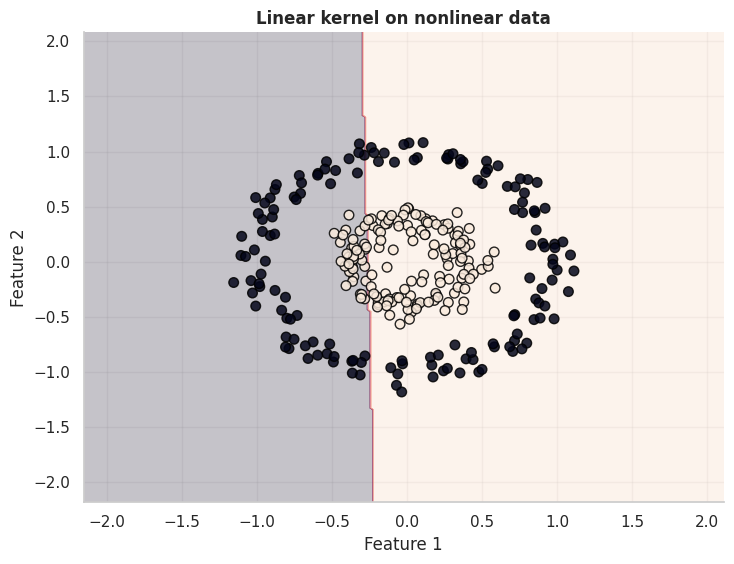

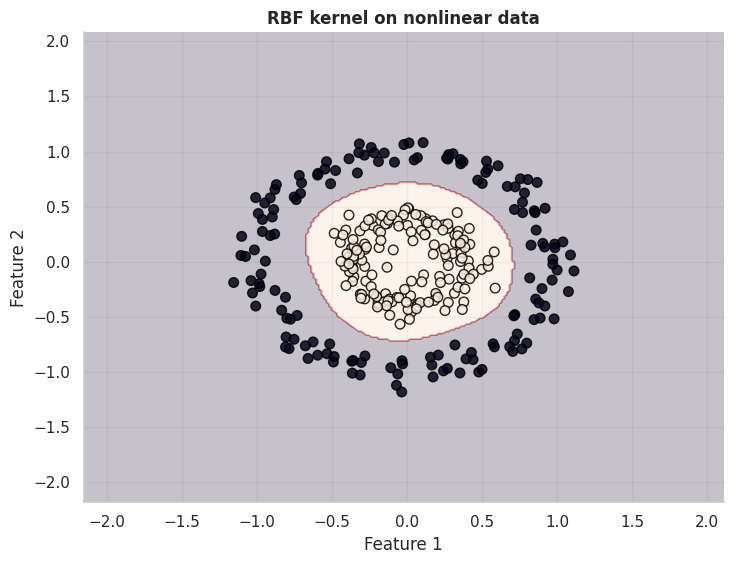

In [6]:

X_circle, y_circle = make_circles(
    n_samples=300,
    factor=0.38,
    noise=0.08,
    random_state=RANDOM_STATE,
)

linear_kernel_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="linear", C=1)),
])
rbf_kernel_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", C=5, gamma=1)),
])

linear_kernel_model.fit(X_circle, y_circle)
rbf_kernel_model.fit(X_circle, y_circle)

plot_2d_classifier(
    linear_kernel_model, X_circle, y_circle,
    "Linear kernel on nonlinear data"
)
plot_2d_classifier(
    rbf_kernel_model, X_circle, y_circle,
    "RBF kernel on nonlinear data"
)



**Interpretation.** The linear model cannot isolate the inner circle. The RBF kernel creates a curved boundary that matches the geometry of the classes. Nonlinear flexibility is valuable only when the data requires it.



## 7. The `gamma` parameter in the RBF kernel

`gamma` controls how local the influence of each observation is.

- **Low `gamma`:** broad influence and smoother boundaries.
- **High `gamma`:** very local influence and more complex boundaries.
- An excessively high value can create small “islands” around individual observations.


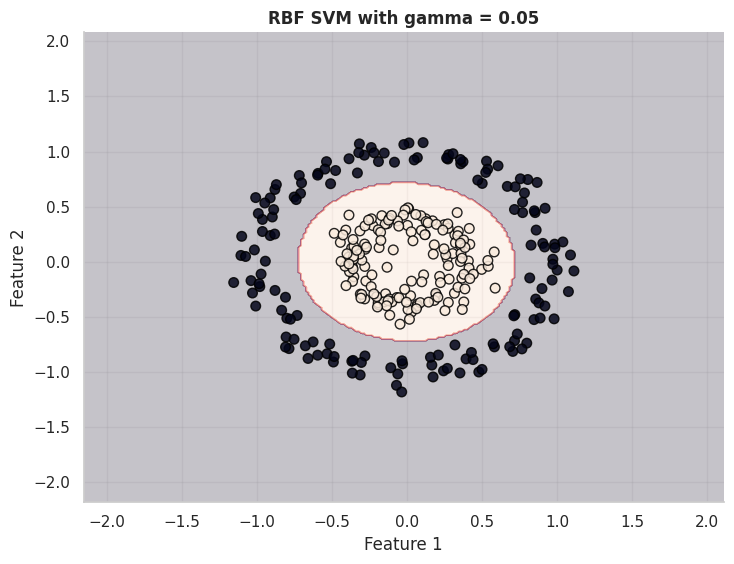

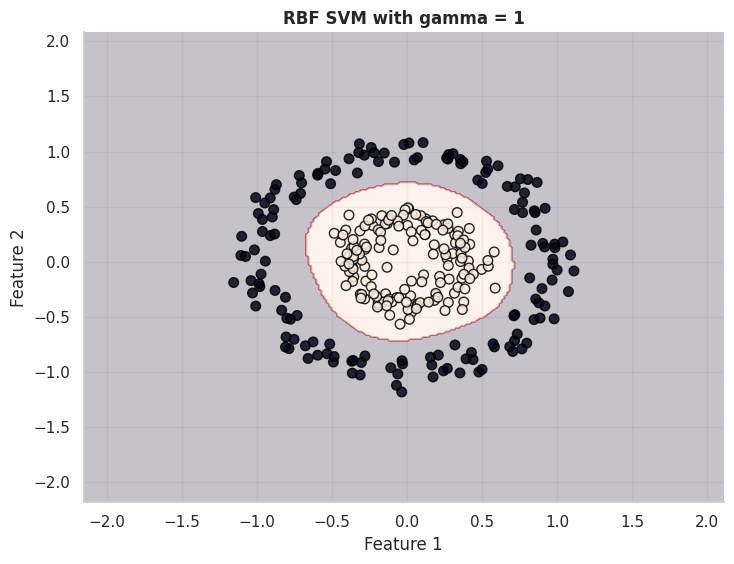

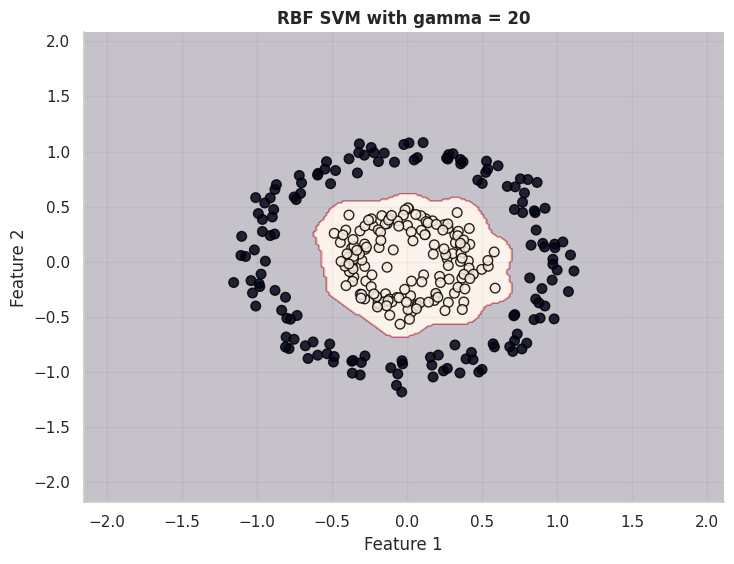

In [7]:

for gamma_value in [0.05, 1, 20]:
    gamma_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=5, gamma=gamma_value)),
    ])
    gamma_model.fit(X_circle, y_circle)
    plot_2d_classifier(
        gamma_model,
        X_circle,
        y_circle,
        title=f"RBF SVM with gamma = {gamma_value}",
    )



**Practical note.** `C` and `gamma` interact. Tune them together inside a pipeline, using cross-validation. Do not select a complex boundary merely because it looks more accurate on the training sample.



# Part B — Linear Discriminant Analysis

## 8. LDA intuition: maximize between-class separation

**Method idea.** LDA models class means, class priors, and a shared covariance structure. It creates linear discriminant directions that increase separation between class centers while controlling within-class scatter.


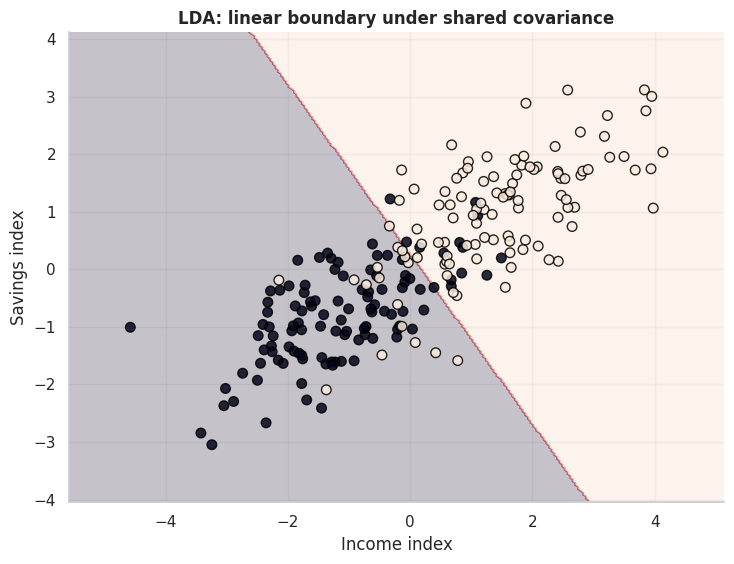

In [8]:

# Two classes with a similar covariance structure.
rng = np.random.default_rng(RANDOM_STATE)
covariance = np.array([[1.4, 0.75], [0.75, 1.0]])

class_0 = rng.multivariate_normal([-1.2, -0.8], covariance, size=110)
class_1 = rng.multivariate_normal([1.4, 1.0], covariance, size=110)

X_lda_toy = np.vstack([class_0, class_1])
y_lda_toy = np.array([0] * len(class_0) + [1] * len(class_1))

lda_toy = LinearDiscriminantAnalysis()
lda_toy.fit(X_lda_toy, y_lda_toy)

plot_2d_classifier(
    lda_toy,
    X_lda_toy,
    y_lda_toy,
    title="LDA: linear boundary under shared covariance",
    feature_names=("Income index", "Savings index"),
)



**Interpretation.** LDA estimates what each class looks like statistically and assigns a new observation using those fitted distributions. The equal-covariance assumption leads to a linear boundary.



## 9. LDA as supervised dimensionality reduction

LDA can also project data onto discriminant axes. Unlike PCA, LDA uses the target labels while finding the projection. For two classes, there is only one discriminant component.


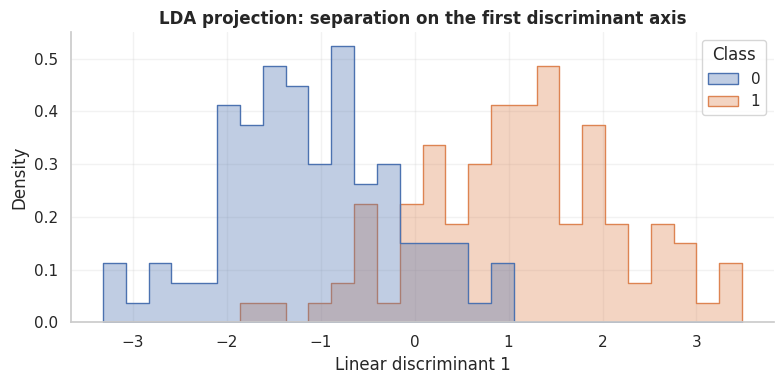

In [9]:

lda_projection = LinearDiscriminantAnalysis(n_components=1)
X_lda_1d = lda_projection.fit_transform(X_lda_toy, y_lda_toy).ravel()

projection_df = pd.DataFrame({
    "LD1": X_lda_1d,
    "Class": y_lda_toy.astype(str),
})

plt.figure(figsize=(8, 4))
sns.histplot(
    data=projection_df,
    x="LD1",
    hue="Class",
    bins=28,
    element="step",
    stat="density",
    common_norm=False,
    alpha=0.35,
)
plt.title("LDA projection: separation on the first discriminant axis")
plt.xlabel("Linear discriminant 1")
plt.tight_layout()
plt.show()



**Interpretation.** The two-dimensional observations have been compressed into one supervised direction. A useful LDA direction keeps observations within each class relatively compact while moving class centers apart.



## 10. LDA assumptions and a visual covariance check

LDA performs best when:

1. class-conditional feature distributions are approximately Gaussian;
2. classes have similar covariance matrices;
3. observations are independent.

These are modeling assumptions, not absolute pass/fail rules. Strong violations are a reason to compare alternatives.


In [10]:

def class_covariance_table(X, y, feature_names):
    rows = []
    for class_value in np.unique(y):
        covariance_matrix = np.cov(X[y == class_value].T)
        rows.append({
            "class": class_value,
            f"variance_{feature_names[0]}": covariance_matrix[0, 0],
            f"variance_{feature_names[1]}": covariance_matrix[1, 1],
            "covariance": covariance_matrix[0, 1],
            "determinant": np.linalg.det(covariance_matrix),
        })
    return pd.DataFrame(rows).round(3)

class_covariance_table(
    X_lda_toy,
    y_lda_toy,
    ["income_index", "savings_index"],
)


,class,variance_income_index,variance_savings_index,covariance,determinant
0,0,1.245,0.693,0.601,0.502
1,1,1.571,1.035,0.838,0.922



**Interpretation.** Similar variances, covariance, and determinant values support the shared-covariance approximation. In higher-dimensional business datasets, inspect this together with cross-validated performance rather than relying on one diagnostic.



## 11. What happens when covariance differs? LDA versus QDA

QDA removes LDA's shared-covariance assumption. Each class receives its own covariance matrix, which can produce a curved boundary. This flexibility requires more parameters and usually more data.


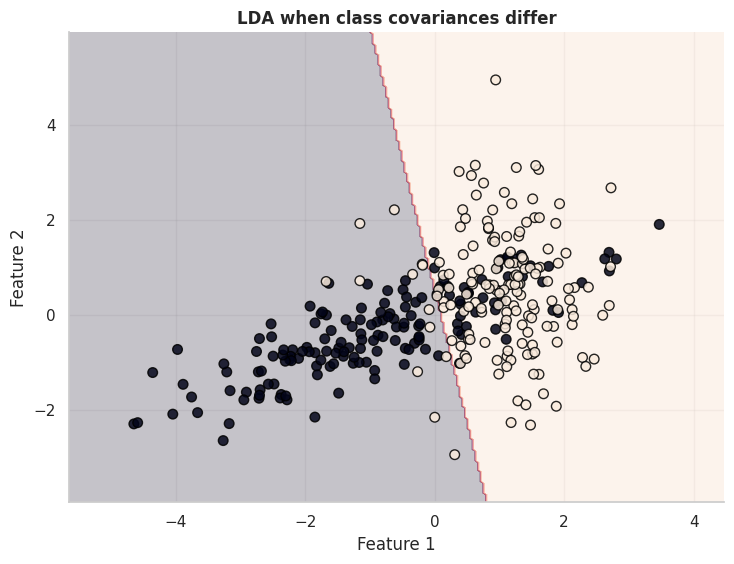

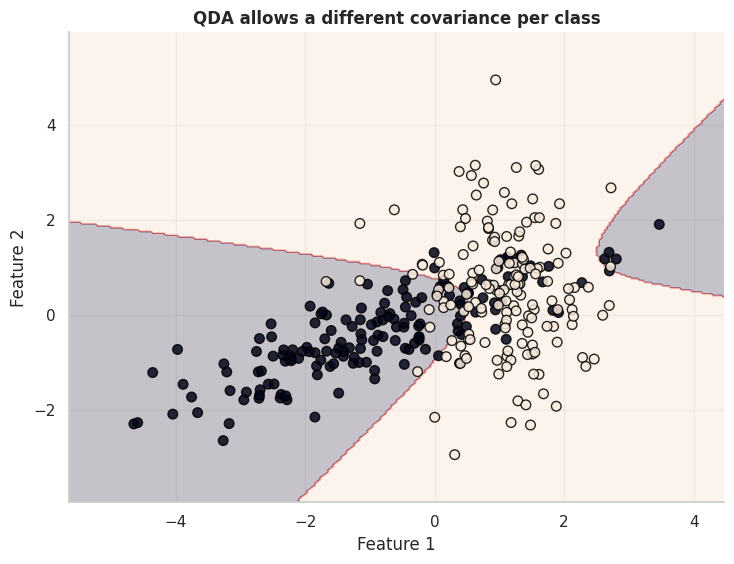

In [11]:

cov_0 = np.array([[2.2, 1.15], [1.15, 0.9]])
cov_1 = np.array([[0.55, -0.20], [-0.20, 1.8]])

class_0_qda = rng.multivariate_normal([-1.0, -0.4], cov_0, size=160)
class_1_qda = rng.multivariate_normal([1.0, 0.6], cov_1, size=160)

X_qda_demo = np.vstack([class_0_qda, class_1_qda])
y_qda_demo = np.array([0] * 160 + [1] * 160)

lda_different_cov = LinearDiscriminantAnalysis().fit(X_qda_demo, y_qda_demo)
qda_model = QuadraticDiscriminantAnalysis().fit(X_qda_demo, y_qda_demo)

plot_2d_classifier(
    lda_different_cov, X_qda_demo, y_qda_demo,
    "LDA when class covariances differ"
)
plot_2d_classifier(
    qda_model, X_qda_demo, y_qda_demo,
    "QDA allows a different covariance per class"
)



**Rule of thumb.**

- Similar class covariance + limited data → start with **LDA**.
- Clearly different covariance + enough observations → compare **QDA**.
- Always confirm the choice with cross-validation.



# Part C — Synthetic business-style dataset

## 12. Generate a reusable credit-rating dataset

The separate file `generate_svm_lda_dataset.py` creates continuous credit features and a binary target. The dataset combines a mostly linear signal with overlap and a mild nonlinear interaction.


In [16]:
credit_df = pd.read_csv("synthetic_svm_lda_credit.csv")
print("Shape:", credit_df.shape)
credit_df.head()


Shape: (500, 7)


,income,savings,debt_ratio,payment_history,transaction_volatility,account_age_years,credit_rating
0,"62,509.240","18,202.490",0.144,74.420,32.070,3.370,0
1,"35,535.770","7,130.710",0.608,96.720,10.260,6.410,0
2,"75,378.550","8,899.100",0.606,69.280,6.580,3.930,0
3,"81,644.170","9,828.720",0.705,78.720,16.840,5.090,0
4,"24,237.440","1,361.780",0.243,80.190,20.800,4.170,0


In [17]:

credit_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   income                  500 non-null    float64
 1   savings                 500 non-null    float64
 2   debt_ratio              500 non-null    float64
 3   payment_history         500 non-null    float64
 4   transaction_volatility  500 non-null    float64
 5   account_age_years       500 non-null    float64
 6   credit_rating           500 non-null    int64  
dtypes: float64(6), int64(1)
memory usage: 27.5 KB


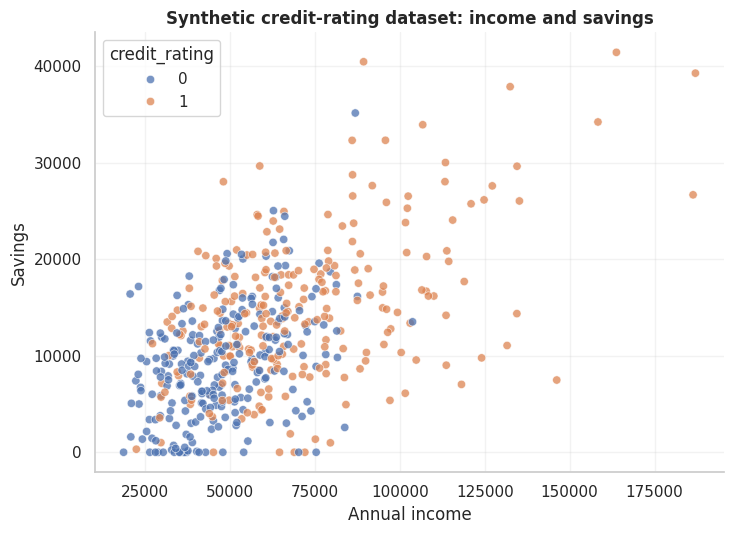

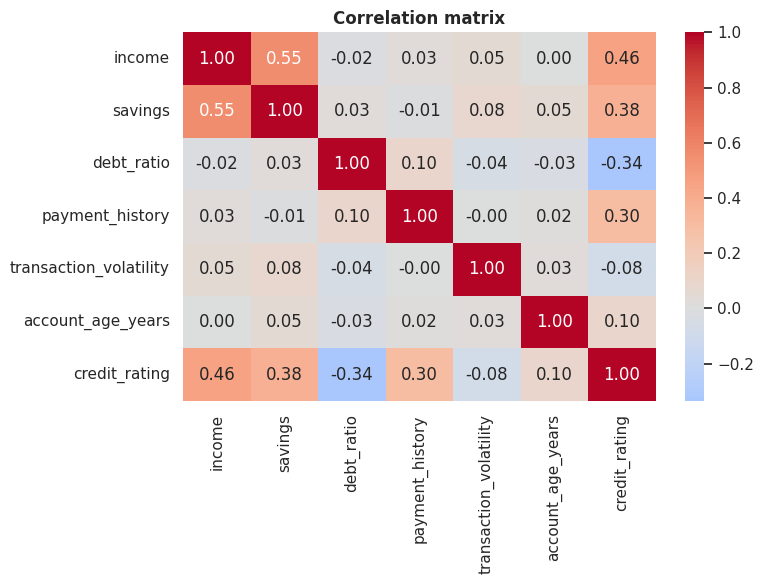

In [18]:

plt.figure(figsize=(7.5, 5.5))
sns.scatterplot(
    data=credit_df,
    x="income",
    y="savings",
    hue="credit_rating",
    alpha=0.75,
)
plt.title("Synthetic credit-rating dataset: income and savings")
plt.xlabel("Annual income")
plt.ylabel("Savings")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(
    credit_df.corr(numeric_only=True),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)
plt.title("Correlation matrix")
plt.tight_layout()
plt.show()



## 13. Compare SVM and LDA on the same train-test split

The models receive the same predictors and target. Scaling is included inside each pipeline to keep preprocessing within the training workflow.


In [19]:

X_credit = credit_df.drop(columns="credit_rating")
y_credit = credit_df["credit_rating"]

X_train, X_test, y_train, y_test = train_test_split(
    X_credit,
    y_credit,
    test_size=0.25,
    stratify=y_credit,
    random_state=RANDOM_STATE,
)

credit_models = {
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1)),
    ]),
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=3, gamma="scale")),
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis()),
    ]),
}

credit_results = []
credit_predictions = {}

for model_name, model in credit_models.items():
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    credit_predictions[model_name] = prediction
    credit_results.append(
        classification_metrics(y_test, prediction, model_name)
    )

pd.concat(credit_results, ignore_index=True).sort_values(
    "weighted_f1", ascending=False
)


,model,accuracy,weighted_f1
2,LDA,0.824,0.824
0,Linear SVM,0.808,0.807
1,RBF SVM,0.808,0.807


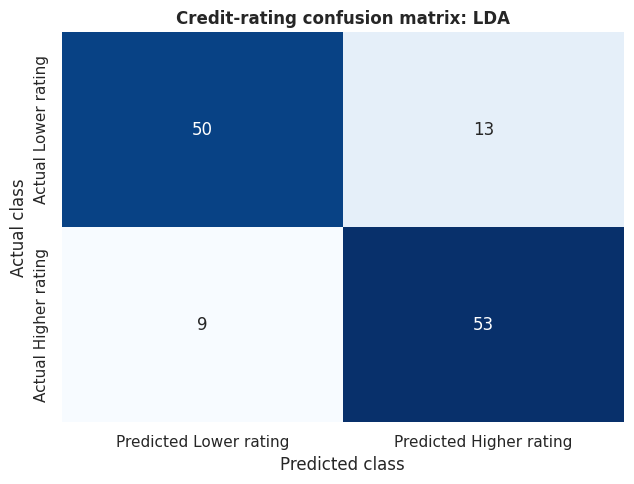

,Predicted Lower rating,Predicted Higher rating
Actual Lower rating,50,13
Actual Higher rating,9,53


In [20]:

best_credit_name = max(
    credit_predictions,
    key=lambda name: f1_score(
        y_test, credit_predictions[name], average="weighted"
    ),
)

plot_confusion(
    y_test,
    credit_predictions[best_credit_name],
    labels=["Lower rating", "Higher rating"],
    title=f"Credit-rating confusion matrix: {best_credit_name}",
)



**Business interpretation.**

- A **false positive** may approve a case that actually belongs to the lower-rating group.
- A **false negative** may reject or unnecessarily review a stronger applicant.
- Accuracy alone is therefore insufficient when the costs of these errors differ.
- LDA is attractive when speed, a stable linear model, and statistical interpretation matter.
- RBF SVM is attractive when cross-validation shows that nonlinear structure materially improves decisions.



# Part D — Realistic multiclass example

## 14. Wine classification

The built-in Wine dataset contains chemical measurements for three wine classes. It is suitable for comparing:

- a linear probabilistic baseline;
- linear and nonlinear SVM;
- LDA as classifier and supervised projection.


In [21]:

wine = load_wine(as_frame=True)
wine_df = wine.frame.copy()

print("Shape:", wine_df.shape)
print("Classes:", dict(enumerate(wine.target_names)))
wine_df.head()


Shape: (178, 14)
Classes: {0: np.str_('class_0'), 1: np.str_('class_1'), 2: np.str_('class_2')}


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.230,1.710,2.430,15.600,127.000,2.800,3.060,0.280,2.290,5.640,1.040,3.920,"1,065.000",0
1,13.200,1.780,2.140,11.200,100.000,2.650,2.760,0.260,1.280,4.380,1.050,3.400,"1,050.000",0
2,13.160,2.360,2.670,18.600,101.000,2.800,3.240,0.300,2.810,5.680,1.030,3.170,"1,185.000",0
3,14.370,1.950,2.500,16.800,113.000,3.850,3.490,0.240,2.180,7.800,0.860,3.450,"1,480.000",0
4,13.240,2.590,2.870,21.000,118.000,2.800,2.690,0.390,1.820,4.320,1.040,2.930,735.000,0


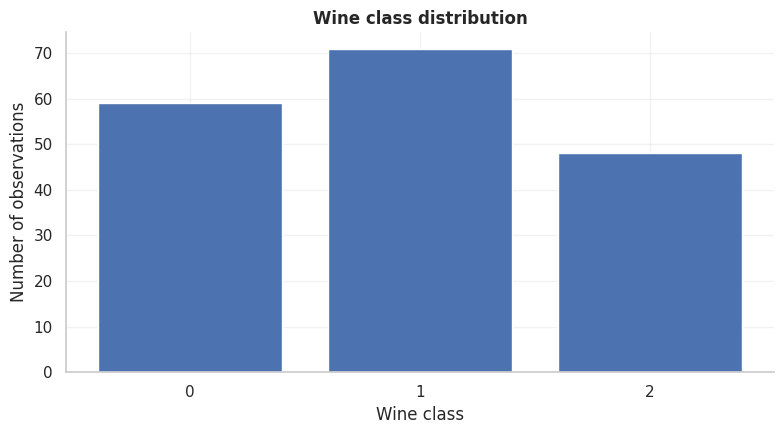

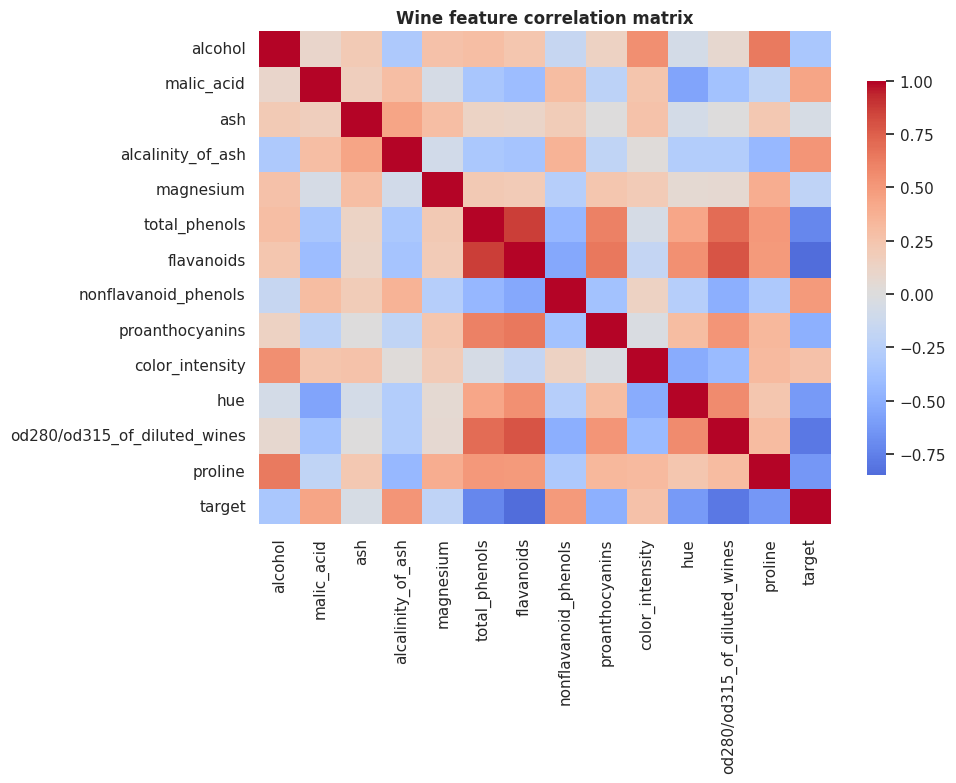

In [22]:

wine_counts = wine_df["target"].value_counts().sort_index()
plt.figure(figsize=(8, 4.5))
plt.bar(wine_counts.index.astype(str), wine_counts.values)
plt.title("Wine class distribution")
plt.xlabel("Wine class")
plt.ylabel("Number of observations")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 8))
sns.heatmap(
    wine_df.corr(numeric_only=True),
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.8},
)
plt.title("Wine feature correlation matrix")
plt.tight_layout()
plt.show()



## 15. Cross-validated model comparison

One holdout split can be unstable. Stratified K-fold cross-validation compares models across several partitions while preserving class proportions.


In [23]:

X_wine = wine.data
y_wine = wine.target

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=3000)),
    ]),
    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="linear", C=1)),
    ]),
    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", C=3, gamma="scale")),
    ]),
    "LDA": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis()),
    ]),
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

cv_rows = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_wine,
        y_wine,
        cv=cv,
        scoring={
            "accuracy": "accuracy",
            "weighted_f1": "f1_weighted",
        },
    )
    cv_rows.append({
        "model": model_name,
        "mean_accuracy": scores["test_accuracy"].mean(),
        "std_accuracy": scores["test_accuracy"].std(),
        "mean_weighted_f1": scores["test_weighted_f1"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values(
    "mean_weighted_f1", ascending=False
).round(3)

cv_results


,model,mean_accuracy,std_accuracy,mean_weighted_f1
0,Logistic Regression,0.983,0.014,0.983
2,RBF SVM,0.983,0.022,0.983
3,LDA,0.983,0.014,0.983
1,Linear SVM,0.966,0.011,0.966


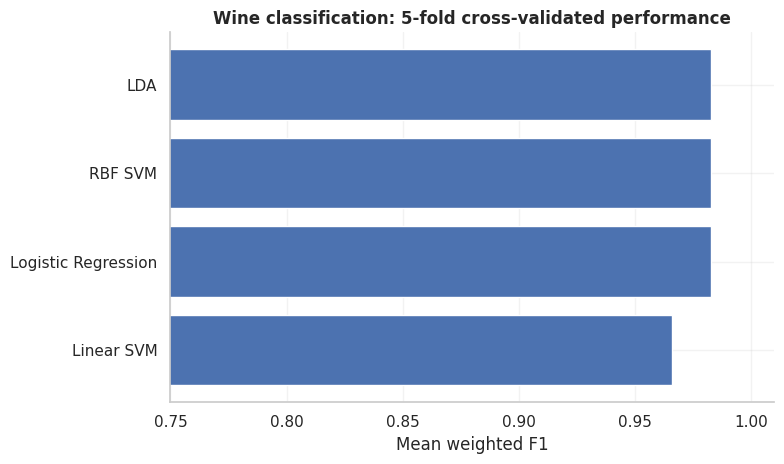

In [24]:

plot_df = cv_results.sort_values("mean_weighted_f1")

plt.figure(figsize=(8, 4.8))
plt.barh(plot_df["model"], plot_df["mean_weighted_f1"])
plt.xlabel("Mean weighted F1")
plt.title("Wine classification: 5-fold cross-validated performance")
plt.xlim(0.75, 1.01)
plt.tight_layout()
plt.show()



**Interpretation.** When several models perform similarly, prefer the simplest model that meets the decision need. LDA is fast and compact; a linear SVM is a strong boundary-focused alternative; an RBF SVM is justified only when its additional flexibility creates reliable cross-validated value.



## 16. Tune the RBF SVM correctly

The parameter search is applied to the complete pipeline. This prevents scaling leakage and evaluates `C` and `gamma` together.


In [25]:

svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf")),
])

parameter_grid = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
}

grid_search = GridSearchCV(
    estimator=svm_pipeline,
    param_grid=parameter_grid,
    scoring="f1_weighted",
    cv=cv,
    n_jobs=-1,
)

grid_search.fit(X_wine, y_wine)

print("Best parameters:", grid_search.best_params_)
print("Best cross-validated weighted F1:", round(grid_search.best_score_, 3))


Best parameters: {'model__C': 1, 'model__gamma': 0.01}
Best cross-validated weighted F1: 0.989


In [26]:

grid_results = pd.DataFrame(grid_search.cv_results_)
grid_results[
    ["param_model__C", "param_model__gamma", "mean_test_score", "std_test_score"]
].sort_values("mean_test_score", ascending=False).head(10).round(3)


,param_model__C,param_model__gamma,mean_test_score,std_test_score
5,1.000,0.010,0.989,0.014
4,1.000,scale,0.983,0.022
10,10.000,0.100,0.983,0.023
8,10.000,scale,0.983,0.023
12,100.000,scale,0.983,0.023
14,100.000,0.100,0.983,0.023
9,10.000,0.010,0.978,0.021
6,1.000,0.100,0.978,0.028
0,0.100,scale,0.972,0.025
13,100.000,0.010,0.966,0.012



## 17. Final holdout evaluation

After model comparison and tuning, the final model is evaluated once on unseen holdout data.


In [27]:

X_train, X_test, y_train, y_test = train_test_split(
    X_wine,
    y_wine,
    test_size=0.25,
    stratify=y_wine,
    random_state=RANDOM_STATE,
)

final_svm = grid_search.best_estimator_
final_lda = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearDiscriminantAnalysis()),
])

final_svm.fit(X_train, y_train)
final_lda.fit(X_train, y_train)

final_predictions = {
    "Tuned RBF SVM": final_svm.predict(X_test),
    "LDA": final_lda.predict(X_test),
}

final_results = pd.concat([
    classification_metrics(y_test, prediction, name)
    for name, prediction in final_predictions.items()
], ignore_index=True)

final_results


,model,accuracy,weighted_f1
0,Tuned RBF SVM,1.000,1.000
1,LDA,0.956,0.955


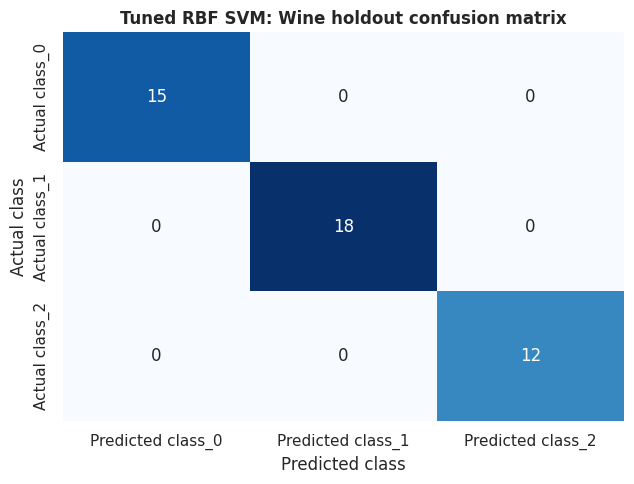

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        15
     class_1       1.00      1.00      1.00        18
     class_2       1.00      1.00      1.00        12

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [28]:

plot_confusion(
    y_test,
    final_predictions["Tuned RBF SVM"],
    labels=wine.target_names,
    title="Tuned RBF SVM: Wine holdout confusion matrix",
)

print(classification_report(
    y_test,
    final_predictions["Tuned RBF SVM"],
    target_names=wine.target_names,
))



## 18. LDA projection of the Wine dataset

With three classes, LDA can produce at most two discriminant components: `n_classes - 1`.


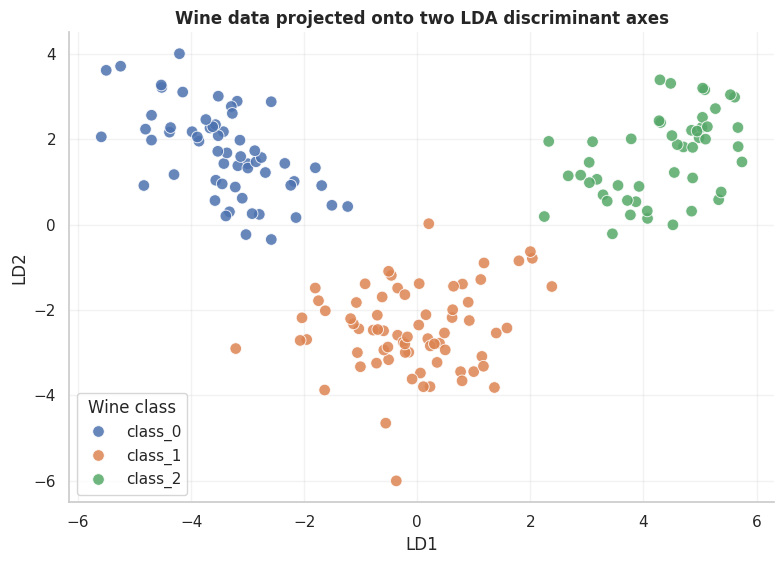

Explained discriminant variance ratio: [0.687 0.313]


In [29]:

wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)

wine_lda_projection = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda = wine_lda_projection.fit_transform(X_wine_scaled, y_wine)

wine_projection_df = pd.DataFrame({
    "LD1": X_wine_lda[:, 0],
    "LD2": X_wine_lda[:, 1],
    "Wine class": [wine.target_names[value] for value in y_wine],
})

plt.figure(figsize=(8, 5.8))
sns.scatterplot(
    data=wine_projection_df,
    x="LD1",
    y="LD2",
    hue="Wine class",
    s=70,
    alpha=0.85,
)
plt.title("Wine data projected onto two LDA discriminant axes")
plt.tight_layout()
plt.show()

print(
    "Explained discriminant variance ratio:",
    np.round(wine_lda_projection.explained_variance_ratio_, 3),
)



**Interpretation.** The projection shows how strongly class labels guide the representation. This is not PCA: PCA searches for overall variance without using the target, whereas LDA explicitly searches for class separation.



# Common mistakes and practical safeguards

### Support Vector Machines

- **Forgetting scaling:** place `StandardScaler` inside a pipeline.
- **Using RBF automatically:** try a linear kernel first when the relationship may be approximately linear or the feature space is large.
- **Tuning on the test set:** select `C` and `gamma` through cross-validation.
- **Interpreting complexity as quality:** a highly irregular boundary may be overfitting.
- **Expecting probabilities by default:** `SVC` does not directly provide them unless `probability=True`, which adds computational cost.

### Linear Discriminant Analysis

- **Ignoring covariance structure:** strongly different class covariances may favor QDA or another classifier.
- **Treating assumptions as guaranteed:** inspect distributions and validate predictive performance.
- **Confusing LDA with PCA:** LDA is supervised; PCA is unsupervised.
- **Using LDA for strongly nonlinear boundaries:** compare SVM, trees, or ensembles.
- **Using too many predictors with too little data:** covariance estimation can become unstable; consider shrinkage or feature reduction.

### General modeling safeguards

- Keep preprocessing inside the cross-validation pipeline.
- Compare several reasonable classifiers.
- Select metrics based on business error costs.
- Evaluate the chosen model once on untouched holdout data.
